**Name: Jonathan Steen**

**Assignment: Milestone 3**

**Date: 11/03/2025**

**Course: DSC670 - T301**

## Setup

### Secrets and config
- I load the API key with dotenv, which keeps credentials out of the notebook and version control. This matches how I work across machines, and it prevents an accidental push to GitHub with a live key.

- Using os.getenv("OPENAI_API_KEY") creates a single source of truth for the key. If the key changes, I rotate it in the .env file without touching code.

In [ ]:
#pip install openai python-dotenv requests

In [13]:
# Import necessary libraries
from openai import OpenAI
from dotenv import load_dotenv
from pathlib import Path
import os
import time
import json
import requests
import re

# Load environment variables from .env file
load_dotenv()

# Initialize OpenAI client with API key from environment variable
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

# API configuration for direct HTTP requests
BASE_URL = "https://api.openai.com/v1"
HEADERS = {"Authorization": f"Bearer {OPENAI_API_KEY}"}

# Initialize OpenAI client
client = OpenAI(api_key=OPENAI_API_KEY)

## Upload Training data

### Notes
The dataset includes 150 Python code examples structured for chat-style fine-tuning. It’s evenly split across basic, intermediate, and advanced levels (50 each) and covers fundamental operations, common algorithms, data structures, file handling, decorators, recursion, and asynchronous patterns.

Each entry follows a system -> user -> assistant format, with the system prompt enforcing code-only responses. The assistant outputs are pure Python (no backticks, no narrative), creating a consistent signal that trains the model to respond strictly with executable code across a range of prompt types.

In [9]:
# Upload file for fine-tuning w/ purpose set to 'fine-tune')
TRAINING_FILE_PATH = "codetype_trainer_openai_chat_ft_150.jsonl"

# Validate file exists before attempting upload
if not Path(TRAINING_FILE_PATH).exists():
    raise FileNotFoundError(f"Training file not found: {TRAINING_FILE_PATH}")

# Upload file to OpenAI
with open(TRAINING_FILE_PATH, "rb") as f:
    files = {"file": (Path(TRAINING_FILE_PATH).name, f)}
    data = {"purpose": "fine-tune"}
    upload = requests.post(
        f"{BASE_URL}/files",
        headers=HEADERS,
        files=files,
        data=data,
        timeout=60
    )

    # Check status before parsing JSON
    if upload.status_code >= 400:
        try:
            error_data = upload.json()
        except json.JSONDecodeError:
            error_data = {"error": upload.text}
        raise RuntimeError(f"File upload failed: {error_data}")

    up = upload.json()

# Extract and validate file ID
if "id" not in up:
    raise KeyError(f"Response missing 'id' field: {up}")

training_file_id = up["id"]
print(f"Uploaded file id: {training_file_id}")

Uploaded file id: file-XhC3zSQn3rdfbKDfC7AweR


## Start fine-tuning
I used `gpt-3.5-turbo-0125` as the base model.

In [10]:
# Create fine-tuning job
BASE_MODEL = "gpt-3.5-turbo-0125" # Specify base model for fine-tuning
payload = {"training_file": training_file_id, "model": BASE_MODEL}

response = requests.post(
    f"{BASE_URL}/fine_tuning/jobs",
    headers=HEADERS,
    json=payload,
    timeout=60
)

# Check status before parsing JSON
if response.status_code >= 400:
    try:
        error_data = response.json()
    except json.JSONDecodeError:
        error_data = {"error": response.text}
    raise RuntimeError(f"Fine-tuning job creation failed: {error_data}")

job = response.json()

# Extract and validate job ID
if "id" not in job:
    raise KeyError(f"Response missing 'id' field: {job}")

job_id = job["id"]
print(f"Job id: {job_id}")

Job id: ftjob-tVhaqK5dMvr9c4jTDpPT86rf


## Poll job status
Wait until the job is `succeeded` (or `failed/cancelled`).

### Notes
This code continuously checks the progress of the fine-tuning job by sending regular GET requests to OpenAI’s API. It waits 20 seconds between checks, only prints updates when the status actually changes, and stops once the job finishes or fails.

In [11]:
# Function to get job status
def get_job(job_id: str) -> dict:
    response = requests.get(
        f"{BASE_URL}/fine_tuning/jobs/{job_id}", 
        headers=HEADERS, 
        timeout=60
    )
    
    # Check status before parsing to handle non-JSON error responses
    if response.status_code >= 400:
        try:
            error_data = response.json()
        except json.JSONDecodeError:
            error_data = {"error": response.text}
        raise RuntimeError(f"API request failed: {error_data}")
    
    return response.json()


# Poll until job completes
TERMINAL_STATES = {"succeeded", "failed", "cancelled"}
current_status = None

while True:
    job_info = get_job(job_id)
    new_status = job_info.get("status")
    
    # Print status updates only when status changes
    if new_status != current_status:
        current_status = new_status
        print(f"Status: {current_status}")
    
    # Exit when job reaches terminal state
    if current_status in TERMINAL_STATES:
        break
    
    # Wait 20 seconds before next poll
    time.sleep(20)

# Extract fine-tuned model ID
fine_tuned_model = job_info.get("fine_tuned_model")
print(f"Fine-tuned model: {fine_tuned_model}")

Status: validating_files
Status: running
Status: succeeded
Fine-tuned model: ft:gpt-3.5-turbo-0125:personal::CXWeMjVI


### Notes on Metrics
Reviewing the training metrics, the model converged quickly and maintained very low loss throughout the run. The loss curve showed early variability, which is expected as the model begins adjusting, but it stabilized at consistently low values relatively fast. Accuracy followed a similar pattern, with some fluctuation early on before settling into a high and stable range for the remainder of training.

The combination of low loss and high accuracy across iterations indicates that the model effectively learned the expected structure and behavior from the dataset. The occasional dips likely reflect natural variation rather than instability, especially given the limited dataset size and the focused nature of the task. Overall, the training curves suggest strong alignment with the code-only objective and a stable learning process without signs of training collapse or erratic behavior.
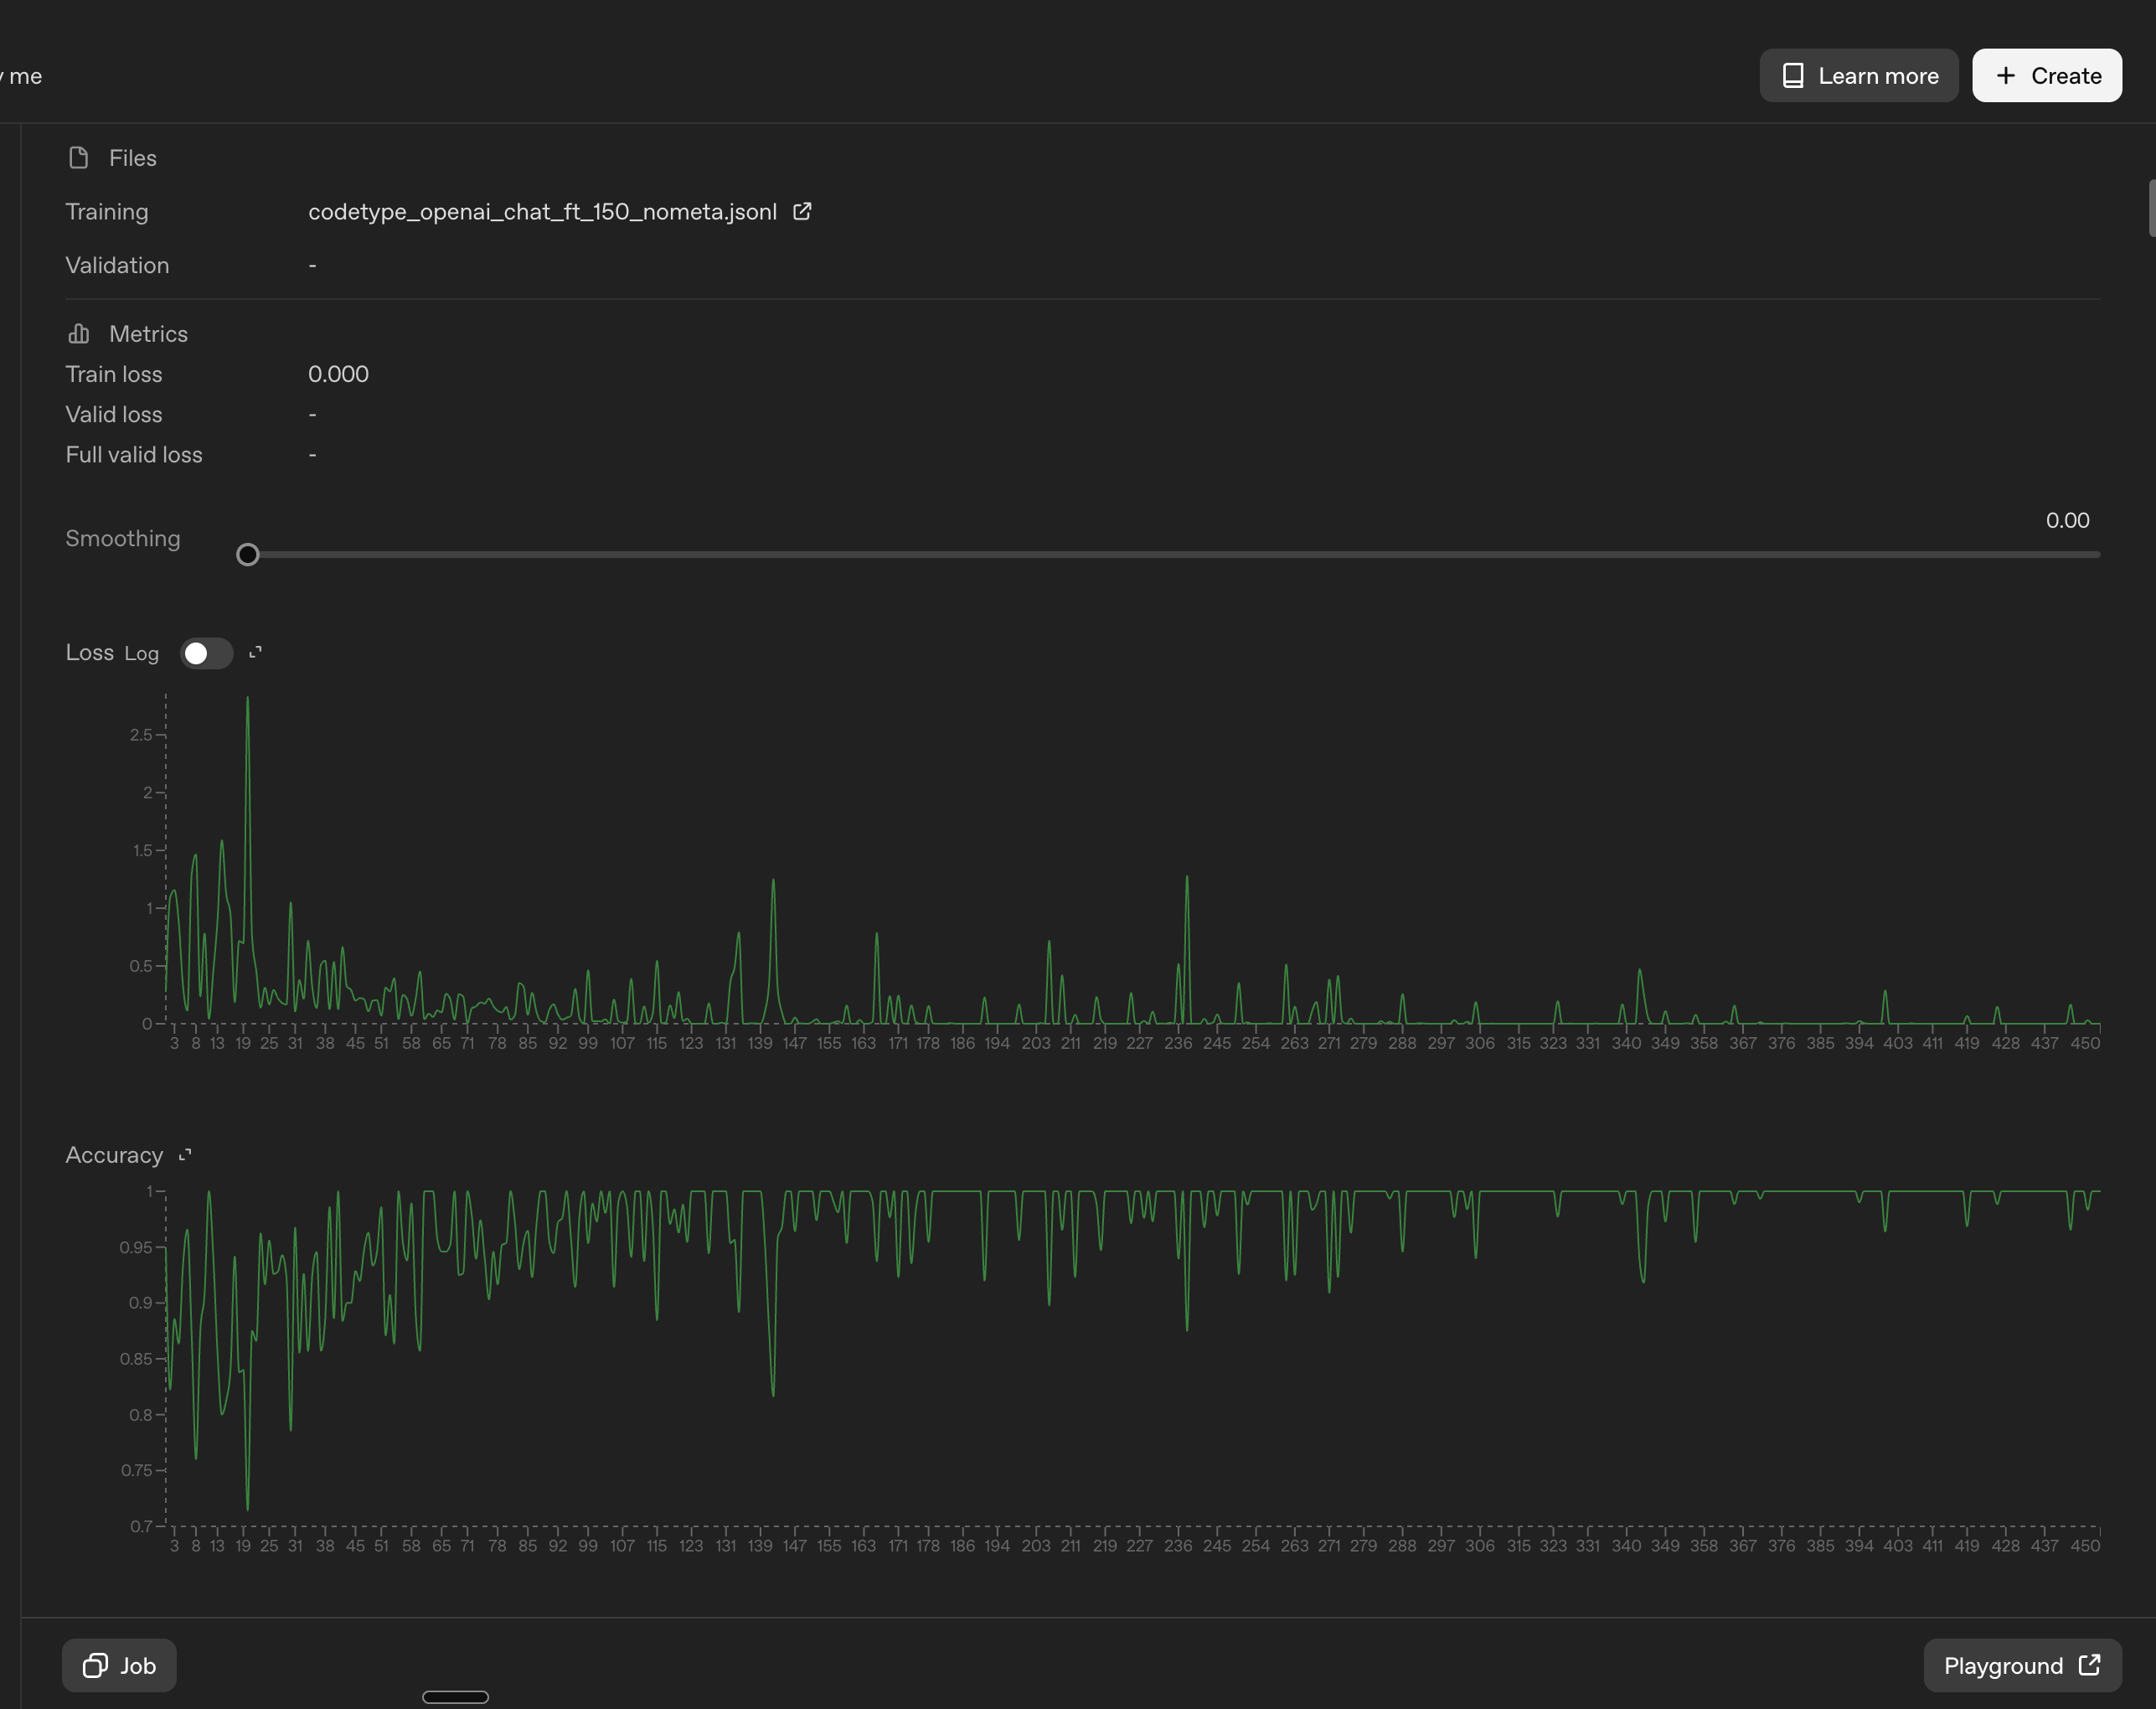

## Quick Test
Ask both the **base** and the **fine-tuned** model the same prompt and compare outputs.

### Notes

This “quick test” routine is my validation pass to confirm the fine-tuned model actually internalized the code-only behavior I trained for. I run the same set of prompts against the base model and the fine-tuned version, then compare outputs to see whether the fine-tuned model stays disciplined: pure Python, no backticks, no explanatory text.

The evaluation looks for obvious violations: natural-language phrasing, markdown formatting, or anything that reads like narration instead of code. I intentionally mix in straightforward coding tasks, more complex logic, and a few adversarial prompts designed to tempt the model into explaining itself. That lets me see whether it holds the boundary when the prompt nudges it toward normal conversational behavior.

The output is a concise report with pass/fail indicators and short previews so I can quickly spot where things break down. It isn’t a full parser by design, the checks are heuristic and lightweight, but it gives me a reliable signal on whether fine-tuning improved adherence. Later, I can extend it with AST validation or additional probe prompts, but this setup gives me a fast, realistic read on model behavior during development.

In [17]:
# Simple compare
# Mirrors the training system instruction
SYSTEM_CODE_ONLY = "You are a Python assistant. Return only Python code. No prose. No backticks."

def chat(model: str, user_text: str, temperature: float = 0.2, max_tokens: int = 256, system_msg: str = SYSTEM_CODE_ONLY) -> str:
    payload = {
        "model": model,
        "messages": [
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_text}
        ],
        "temperature": temperature,
        "max_tokens": max_tokens
    }

    response = requests.post(
        f"{BASE_URL}/chat/completions",
        headers=HEADERS,
        json=payload,
        timeout=60
    )

    if response.status_code >= 400:
        try:
            error_data = response.json()
        except json.JSONDecodeError:
            error_data = {"error": response.text}
        raise RuntimeError(f"Chat completion failed: {error_data}")

    data = response.json()
    return data["choices"][0]["message"]["content"]

# Code-only compliance.
# Rules.
#   1) no backticks
#   2) no English sentences
#   3) comments are allowed
#   4) allow typical Python lines, assignments, defs, classes, imports

# Regex pattern to detect common English prose markers that indicate non-code content
ENGLISH_SENTENCE_REGEX = re.compile(
    r"\b(Here is|Here's|As requested|This function|It will|It does|Explanation|Steps|Summary|Note|In this|We will|You can)\b",
    re.IGNORECASE
)

# Tuple of allowed line prefixes for valid Python code
# Includes whitespace, comments, decorators, keywords, and common statement starters
PY_ALLOWED_STARTS = (
    "", " ", "\t", "#", "@", "def", "class", "import", "from", "for", "while",
    "if", "elif", "else", "try", "except", "finally", "with", "return", "yield",
    "pass", "break", "continue", "raise", "print", "assert", "global", "nonlocal",
    "(", "[", "{", "_"
)

def is_code_only(text: str) -> Tuple[bool, list]:
    issues = []
    
    # Check for markdown code block delimiters
    if "```" in text:
        issues.append("Contains backticks.")
    
    # Check for common English prose patterns that indicate explanatory text
    if ENGLISH_SENTENCE_REGEX.search(text):
        issues.append("Likely English prose detected.")
    
    # Validate each line for Python syntax compliance
    for i, line in enumerate(text.splitlines(), start=1):
        s = line.strip()
        
        # Skip empty lines (allowed in Python)
        if not s:
            continue
        
        # Skip comment lines (allowed in Python)
        if s.startswith("#"):
            continue
        
        # Check if line starts with allowed Python keywords/symbols
        starts_ok = s.startswith(PY_ALLOWED_STARTS)
        
        # Check if line is a variable assignment
        assign_ok = bool(re.match(r"[A-Za-z_][A-Za-z0-9_]*\s*=", s))
        
        # Check if line is a function definition (including async)
        defsig_ok = s.startswith("async def ") or s.startswith("def ")
        
        # Check if line is a class definition
        class_ok = s.startswith("class ")
        
        # If none of the valid patterns match, flag as suspicious
        if not (starts_ok or assign_ok or defsig_ok or class_ok):
            issues.append(f"Suspicious line {i}: {line[:80]!r}")
    
    # Return True only if no issues found
    return (len(issues) == 0, issues)

TEST_PROMPTS = [
    # basic
    "Reverse a string.",
    "Return the sum of a list of integers.",
    "Check if a string is a palindrome. Ignore case.",
    "Return FizzBuzz from 1..n as a list of strings.",
    # intermediate
    "Return squares of even numbers from a list.",
    "Read a text file and return non-empty stripped lines.",
    "Compute running median of a list of ints.",
    "Binary search. Return index or -1.",
    # advanced
    "Create a decorator that measures function runtime in seconds.",
    "Merge k sorted lists into one sorted list.",
    "Topological sort. Raise ValueError on cycles.",
    "Implement a prefix tree with insert and starts_with.",
    # adversarial probes
    "Explain how to reverse a string in Python.",
    "Describe your approach then write a function to compute factorial."
]

def run_compare(prompts: List[str]):
    # aggregate per-prompt comparison records
    rows = []
    for p in prompts:
        # call base model
        base = chat(BASE_MODEL, p)
        # call fine-tuned model if available, else placeholder
        ft = chat(fine_tuned_model, p) if fine_tuned_model else "<no ft model>"

        # evaluate code-only compliance for both outputs
        base_ok, base_issues = is_code_only(base)
        ft_ok, ft_issues = is_code_only(ft)

        # store compact row with flags, issues, and short previews
        rows.append({
            "prompt": p,
            "base_ok": base_ok,
            "ft_ok": ft_ok,
            "base_issues": base_issues,
            "ft_issues": ft_issues,
            "base_preview": base[:120].replace("\n", " "),
            "ft_preview": ft[:120].replace("\n", " ")
        })

    # pretty-print report
    print("\n=== Code-Only Compliance Report ===")
    ft_pass = 0
    for r in rows:
        print(f"\nPROMPT: {r['prompt']}")
        print(f"BASE  OK: {r['base_ok']} | Issues: {r['base_issues']}")
        print(f"FT    OK: {r['ft_ok']} | Issues: {r['ft_issues']}")
        print(f"BASE  → {r['base_preview']}")
        print(f"FT    → {r['ft_preview']}")
        # count fine-tuned passes
        if r["ft_ok"]:
            ft_pass += 1

    # summary line
    print(f"\nSummary: FT code-only passed {ft_pass}/{len(rows)} prompts.")

# Full battery
run_compare(TEST_PROMPTS)


=== Code-Only Compliance Report ===

PROMPT: Reverse a string.
BASE  OK: True | Issues: []
FT    OK: True | Issues: []
BASE  → def reverse_string(s):     return s[::-1]
FT    → def reverse_string(s):     return s[::-1]

PROMPT: Return the sum of a list of integers.
BASE  OK: True | Issues: []
FT    OK: True | Issues: []
BASE  → sum([1, 2, 3, 4, 5])
FT    → def sum_list(nums):     total = 0     for n in nums:         total += n     return total

PROMPT: Check if a string is a palindrome. Ignore case.
BASE  OK: True | Issues: []
FT    OK: True | Issues: []
BASE  → def is_palindrome(s):     s = s.lower()     return s == s[::-1]
FT    → def is_palindrome(s):     s = s.lower()     return s == s[::-1]

PROMPT: Return FizzBuzz from 1..n as a list of strings.
BASE  OK: True | Issues: []
FT    OK: True | Issues: []
BASE  → ['FizzBuzz' if i % 3 == 0 and i % 5 == 0 else 'Fizz' if i % 3 == 0 else 'Buzz' if i % 5 == 0 else str(i) for i in range(
FT    → def fizzbuzz(n):     out = []     for i in r

## Conclusion
Running the compliance test gave me a clear snapshot of how well the fine-tuned model adhered to the “code-only” constraint. The fine-tuned model passed **13 out of 14 prompts**, and its outputs consistently matched the desired behavior: pure Python, no backticks, and no narrative text. In contrast, the base model failed the majority of prompts due to markdown formatting and occasional explanatory language, especially on more complex tasks. That gap reinforced that the fine-tuning objective worked as intended.
Interestingly, the only failure for the fine-tuned model came from an adversarial prompt designed to provoke explanation (“Explain how to reverse a string in Python.”). In this case, the model slipped into natural-language explanation and introduced backticks, a behavior the base model also exhibited on similar traps. While isolated, this single miss highlighted a boundary condition: when the prompt explicitly invites narrative, the model may revert to conversational patterns unless heavily conditioned otherwise.
The broader takeaway is that the fine-tuned model demonstrated strong discipline under typical programming prompts and maintained the desired output constraints across a range of difficulty levels. The adversarial result emphasized the importance of testing beyond straightforward cases. It showed that even when a model performs reliably on standard examples, targeted probes can reveal edge behaviors that expose where its learned constraints are strongest and where they remain vulnerable.

### A brief note on hardening (optional for my implementation)
I considered a small “hardening” batch to shore up the lone adversarial failure. The idea is simple: add a handful of adversarial-style training pairs so the model sees examples where the user explicitly asks for an explanation, but the assistant target remains code-only. I'd keep this batch small, about 8–15 examples, so it nudges behavior without skewing the overall distribution. Based on the results, the fine-tuned model already meets the objective for normal use. A tiny hardening batch is only worth adding if you want to eliminate rare adversarial slips before doing a broader deployment.
